# Data Cleaning & Preparation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_parquet(
    "../data/raw/yellow_tripdata_2026-01.parquet"
)

## Preserve the raw dataset

In [3]:
df_raw = df.copy(deep=True)

df_clean = df_raw.copy(deep=True)

In [4]:
print("Raw shape:", df_raw.shape)
print("Clean shape:", df_clean.shape)

print("Are they equal?", df_raw.equals(df_clean))

Raw shape: (3724889, 20)
Clean shape: (3724889, 20)
Are they equal? True


## Duplicate handling

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
duplicate_count = df_clean.duplicated().sum()

print("Exact duplicates:", duplicate_count)

Exact duplicates: 0


In [7]:
df_clean = df_clean.drop_duplicates().copy()

In [ ]:
#Just to be on the safer side, let's check the number of duplicates again after dropping them
print("Raw rows:", len(df_raw))
print("After duplicate removal:", len(df_clean))

print("Remaining duplicates:", df_clean.duplicated().sum())

Raw rows: 3724889
After duplicate removal: 3724889
Remaining duplicates: 0


## Missing-value treatment

In [9]:
missing_summary = pd.DataFrame({
    "missing_count": df_clean.isnull().sum(),
    "missing_percentage": df_clean.isnull().mean() * 100
})

missing_summary.sort_values(
    "missing_percentage",
    ascending=False
)

,missing_count,missing_percentage
passenger_count,1088058,29.210481
congestion_surcharge,1088058,29.210481
store_and_fwd_flag,1088058,29.210481
RatecodeID,1088058,29.210481
Airport_fee,1088058,29.210481
tpep_dropoff_datetime,0,0.000000
VendorID,0,0.000000
tpep_pickup_datetime,0,0.000000
DOLocationID,0,0.000000
payment_type,0,0.000000


In [10]:
missing_pickup = df_clean[
    df_clean["tpep_pickup_datetime"].isnull()
]

missing_dropoff = df_clean[
    df_clean["tpep_dropoff_datetime"].isnull()
]

print("Missing pickup:", len(missing_pickup))
print("Missing dropoff:", len(missing_dropoff))

Missing pickup: 0
Missing dropoff: 0


In [13]:
#To be on the safer side
df_clean = df_clean.dropna(
    subset=[
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime"
    ]
).copy()

## Handling invalid records

In [11]:
negative_distance = df_clean[
    df_clean["trip_distance"] < 0
]

print("Negative distances:", len(negative_distance))

Negative distances: 0


In [12]:
negative_distance[[
    "trip_distance",
    "fare_amount",
    "total_amount",
    "payment_type"
]].head(10)

,trip_distance,fare_amount,total_amount,payment_type


In [14]:
df_clean = df_clean[
    df_clean["trip_distance"] >= 0
].copy()

In [15]:
df_clean["trip_duration_minutes"] = (
    df_clean["tpep_dropoff_datetime"] -
    df_clean["tpep_pickup_datetime"]
).dt.total_seconds() / 60

In [16]:
df_clean = df_clean[
    df_clean["trip_duration_minutes"] >= 0
].copy()

In [19]:
df_clean["zero_duration_flag"] = (
    df_clean["trip_duration_minutes"] == 0
)

df_clean["zero_distance_flag"] = (
    df_clean["trip_distance"] == 0
)

Q1 = df["trip_distance"].quantile(0.25)

Q3 = df["trip_distance"].quantile(0.75)

IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
df_clean["extreme_distance_flag"] = (
    df_clean["trip_distance"] > upper_bound
)

df_clean["long_duration_flag"] = (
    df_clean["trip_duration_minutes"] > 1440
)

## Outlier treatment

In [20]:
print(
    "Extreme distance records:",
    df_clean["extreme_distance_flag"].sum()
)

Extreme distance records: 421949


In [21]:
df_distance_visual = df_clean[
    ~df_clean["extreme_distance_flag"]
].copy()

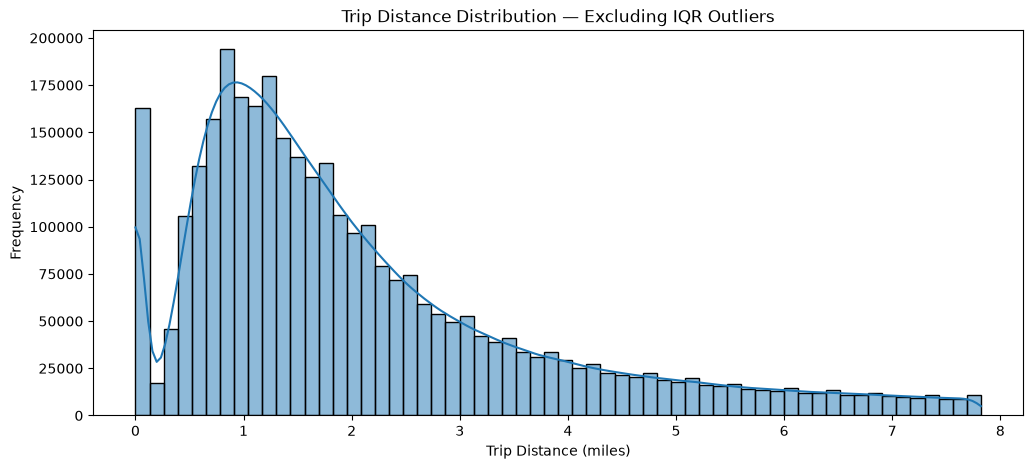

In [22]:
plt.figure(figsize=(12, 5))

sns.histplot(
    data=df_distance_visual,
    x="trip_distance",
    bins=60,
    kde=True
)

plt.title("Trip Distance Distribution — Excluding IQR Outliers")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Frequency")

plt.show()

In [23]:
comparison = pd.DataFrame({
    "Original": df_clean["trip_distance"].describe(),
    "Without IQR outliers": df_distance_visual["trip_distance"].describe()
})

comparison

,Original,Without IQR outliers
count,3.724888e+06,3.302939e+06
mean,6.455644e+00,2.101342e+00
std,6.488856e+02,1.677513e+00
min,0.000000e+00,0.000000e+00
25%,1.000000e+00,9.200000e-01
50%,1.810000e+00,1.600000e+00
75%,3.730000e+00,2.780000e+00
max,2.690975e+05,7.820000e+00


## Datetime preparation

In [24]:
df_clean["pickup_date"] = (
    df_clean["tpep_pickup_datetime"].dt.date
)

df_clean["pickup_hour"] = (
    df_clean["tpep_pickup_datetime"].dt.hour
)

df_clean["pickup_day"] = (
    df_clean["tpep_pickup_datetime"].dt.day
)

df_clean["pickup_day_name"] = (
    df_clean["tpep_pickup_datetime"].dt.day_name()
)

df_clean["pickup_weekday"] = (
    df_clean["tpep_pickup_datetime"].dt.dayofweek
)

df_clean["pickup_month"] = (
    df_clean["tpep_pickup_datetime"].dt.month
)

df_clean["pickup_year"] = (
    df_clean["tpep_pickup_datetime"].dt.year
)

In [25]:
def classify_day_period(hour):

    if 5 <= hour < 12:
        return "Morning"

    elif 12 <= hour < 17:
        return "Afternoon"

    elif 17 <= hour < 21:
        return "Evening"

    else:
        return "Night"

In [26]:
df_clean["pickup_period"] = (
    df_clean["pickup_hour"].apply(classify_day_period)
)

In [27]:
df_clean["pickup_period"].value_counts()

pickup_period
Afternoon    1040220
Evening       965171
Night         871078
Morning       848419
Name: count, dtype: int64

## Create useful analytical features

In [28]:
df_clean["average_speed_mph"] = np.nan

valid_duration = df_clean["trip_duration_minutes"] > 0

df_clean.loc[
    valid_duration,
    "average_speed_mph"
] = (
    df_clean.loc[valid_duration, "trip_distance"] /
    (
        df_clean.loc[valid_duration, "trip_duration_minutes"] / 60
    )
)

In [29]:
df_clean["fare_per_mile"] = np.nan

valid_distance = df_clean["trip_distance"] > 0

df_clean.loc[
    valid_distance,
    "fare_per_mile"
] = (
    df_clean.loc[valid_distance, "fare_amount"] /
    df_clean.loc[valid_distance, "trip_distance"]
)

In [30]:
df_clean["is_weekend"] = (
    df_clean["pickup_weekday"] >= 5
)

## Before-and-after validation

In [31]:
cleaning_summary = pd.DataFrame({
    "Stage": [
        "Raw dataset",
        "After duplicate removal",
        "After missing timestamp removal",
        "After negative distance removal",
        "After negative duration removal"
    ],

    "Rows": [
        len(df_raw),
        len(df_raw.drop_duplicates()),
        len(df_raw.drop_duplicates().dropna(
            subset=[
                "tpep_pickup_datetime",
                "tpep_dropoff_datetime"
            ]
        )),
        len(
            df_raw.drop_duplicates()
            .dropna(
                subset=[
                    "tpep_pickup_datetime",
                    "tpep_dropoff_datetime"
                ]
            )
            .query("trip_distance >= 0")
        ),
        len(df_clean)
    ]
})

cleaning_summary

,Stage,Rows
0,Raw dataset,3724889
1,After duplicate removal,3724889
2,After missing timestamp removal,3724889
3,After negative distance removal,3724889
4,After negative duration removal,3724888


In [32]:
total_removed = len(df_raw) - len(df_clean)

removal_percentage = (
    total_removed / len(df_raw)
) * 100

print("Original rows:", len(df_raw))
print("Clean rows:", len(df_clean))
print("Removed rows:", total_removed)
print("Removal percentage:", removal_percentage)

Original rows: 3724889
Clean rows: 3724888
Removed rows: 1
Removal percentage: 2.6846437571696765e-05


In [34]:
before_after = pd.concat(
    {
        "Raw": df_raw[
            [
                "trip_distance",
                "fare_amount",
                "total_amount",
                "passenger_count"
            ]
        ].describe().loc[
            ["mean", "50%", "std", "min", "max"]
        ],

        "Cleaned": df_clean[
            [
                "trip_distance",
                "fare_amount",
                "total_amount",
                "passenger_count"
            ]
        ].describe().loc[
            ["mean", "50%", "std", "min", "max"]
        ]
    },
    axis=1
)

before_after

Raw                                                  Cleaned  \
      trip_distance  fare_amount total_amount passenger_count  trip_distance   
mean       6.455647    20.804254    29.178526        1.256271       6.455644   
50%        1.810000    15.600000    23.050000        1.000000       1.810000   
std      648.885528    18.927007    22.585530        0.670243     648.885616   
min        0.000000 -2555.200000 -2560.200000        0.000000       0.000000   
max   269097.480000  2555.200000  2560.200000        9.000000  269097.480000   

                                                
      fare_amount total_amount passenger_count  
mean    20.804242    29.178515        1.256271  
50%     15.600000    23.050000        1.000000  
std     18.926995    22.585524        0.670243  
min  -2555.200000 -2560.200000        0.000000  
max   2555.200000  2560.200000        9.000000

In [35]:
df_clean.to_parquet(
    "../data/processed/taxi_trip_cleaned.parquet",
    index=False
)

In [36]:
df_clean = pd.read_parquet(
    "../data/processed/taxi_trip_cleaned.parquet"
)